In [ ]:
# ╔═══════════════════════════════════════════════════════════════╗
# ║   HOW LLMS PROCESS WORDS - INTERACTIVE DEMO                   ║
# ║  From Text → Tokens → Embeddings → Vector Space               ║
# ╚═══════════════════════════════════════════════════════════════╝

# Install required libraries (first time only)
!pip install transformers torch scikit-learn matplotlib seaborn plotly -q

# Import libraries
import numpy as np
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
from IPython.display import display, Markdown, HTML
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ All libraries loaded successfully!")



✅ All libraries loaded successfully!


In [ ]:
# ╔═══════════════════════════════════════════════════════════════╗
# ║  STEP 1: LOAD THE MODEL                                       ║
# ╚═══════════════════════════════════════════════════════════════╝

display(Markdown("## 📥 Loading BERT Model and Tokenizer..."))
display(Markdown("*This may take 1-2 minutes on first run*"))

# Load pre-trained BERT model and tokenizer
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
model = AutoModel.from_pretrained('bert-base-uncased')

display(Markdown("✅ **Model loaded successfully!**"))
display(Markdown(f"**Model type:** {model.config.model_type}"))
display(Markdown(f"**Hidden size:** {model.config.hidden_size} dimensions"))



## 📥 Loading BERT Model and Tokenizer...

*This may take 1-2 minutes on first run*

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ **Model loaded successfully!**

**Model type:** bert

**Hidden size:** 768 dimensions

## ✂️ STEP 2: TOKENIZATION

Watch how text gets broken into tokens...

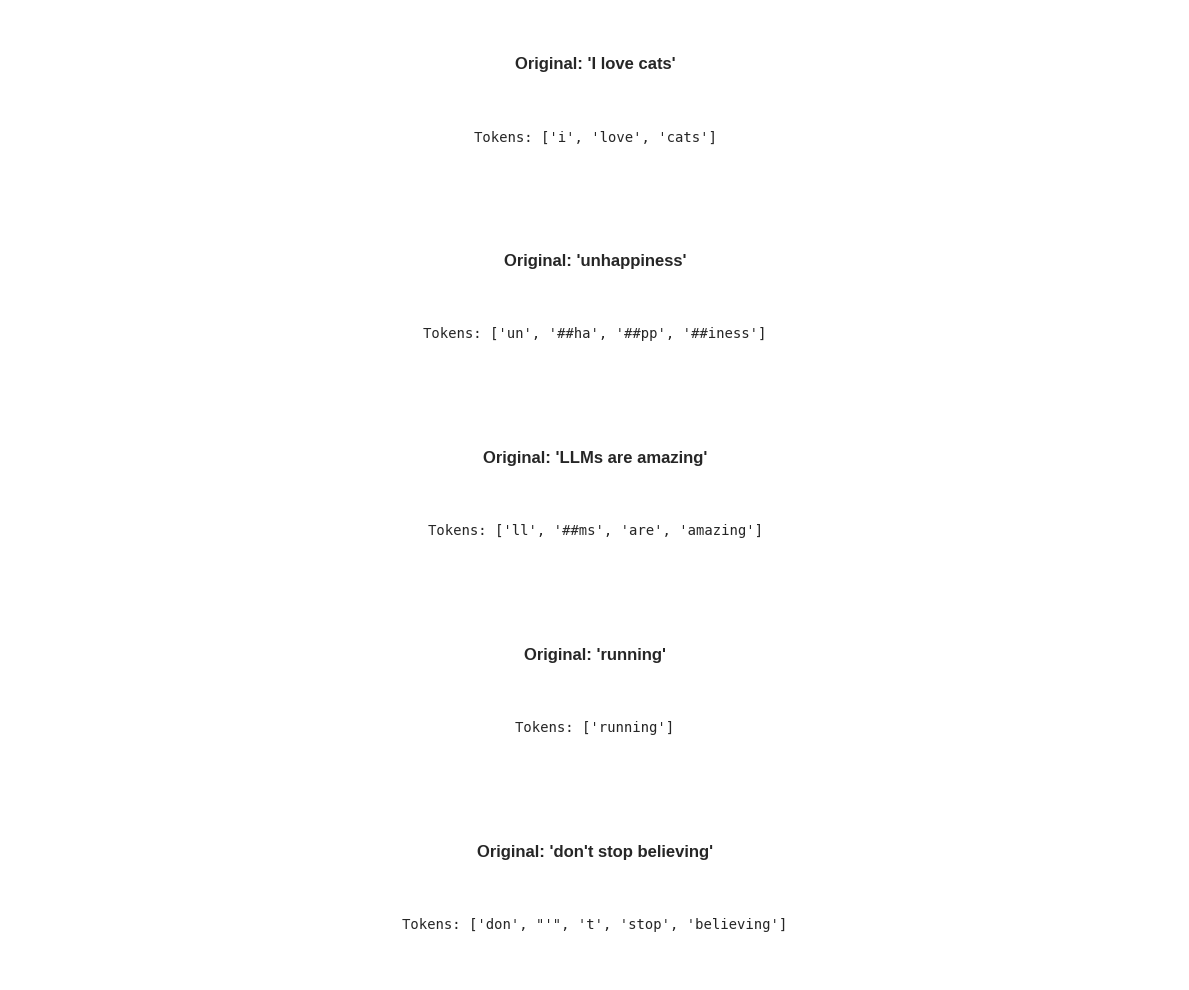

### 📊 Detailed Tokenization Breakdown


**Text:** `I love cats`
- **Tokens:** `['i', 'love', 'cats']`
- **Token IDs:** `[101, 1045, 2293, 8870, 102]`
- **Count:** 3 tokens



**Text:** `unhappiness`
- **Tokens:** `['un', '##ha', '##pp', '##iness']`
- **Token IDs:** `[101, 4895, 3270, 9397, 9961, 102]`
- **Count:** 4 tokens



**Text:** `LLMs are amazing`
- **Tokens:** `['ll', '##ms', 'are', 'amazing']`
- **Token IDs:** `[101, 2222, 5244, 2024, 6429, 102]`
- **Count:** 4 tokens



**Text:** `running`
- **Tokens:** `['running']`
- **Token IDs:** `[101, 2770, 102]`
- **Count:** 1 tokens



**Text:** `don't stop believing`
- **Tokens:** `['don', "'", 't', 'stop', 'believing']`
- **Token IDs:** `[101, 2123, 1005, 1056, 2644, 8929, 102]`
- **Count:** 5 tokens


In [ ]:
# ╔═══════════════════════════════════════════════════════════════╗
# ║  STEP 2: TOKENIZATION DEMO                                    ║
# ╚═══════════════════════════════════════════════════════════════╝

display(Markdown("## ✂️ STEP 2: TOKENIZATION"))
display(Markdown("Watch how text gets broken into tokens..."))

# Examples to tokenize
examples = [
    "I love cats",
    "unhappiness",
    "LLMs are amazing",
    "running",
    "don't stop believing"
]

# Create visualization
fig, axes = plt.subplots(len(examples), 1, figsize=(12, 2*len(examples)))
if len(examples) == 1:
    axes = [axes]

for idx, (text, ax) in enumerate(zip(examples, axes)):
    # Tokenize
    tokens = tokenizer.tokenize(text)
    token_ids = tokenizer.encode(text, add_special_tokens=True)

    # Display
    ax.text(0.5, 0.7, f"Original: '{text}'", ha='center', va='center',
            fontsize=12, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.3, f"Tokens: {tokens}", ha='center', va='center',
            fontsize=10, fontfamily='monospace', transform=ax.transAxes)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_facecolor('#f0f0f0')

plt.tight_layout()
plt.show()

# Detailed breakdown
display(Markdown("### 📊 Detailed Tokenization Breakdown"))
for text in examples:
    tokens = tokenizer.tokenize(text)
    token_ids = tokenizer.encode(text, add_special_tokens=True)

    display(Markdown(f"""
**Text:** `{text}`
- **Tokens:** `{tokens}`
- **Token IDs:** `{token_ids}`
- **Count:** {len(tokens)} tokens
"""))



In [ ]:
# ╔═══════════════════════════════════════════════════════════════╗
# ║  STEP 3: GENERATE EMBEDDINGS                                  ║
# ╚═══════════════════════════════════════════════════════════════╝

display(Markdown("## 🔢 STEP 3: WORD EMBEDDINGS"))
display(Markdown("Converting words into high-dimensional vectors..."))

# Words to embed
words = ["cat", "dog", "kitten", "puppy", "car", "truck",
         "apple", "banana", "happy", "joyful", "sad"]

display(Markdown(f"### Embedding {len(words)} words..."))

# Generate embeddings
embeddings = {}
for word in words:
    inputs = tokenizer(word, return_tensors='pt')
    with torch.no_grad():
        outputs = model(**inputs)
    # Get the [CLS] token embedding (first token)
    embedding = outputs.last_hidden_state[0, 0, :].numpy()
    embeddings[word] = embedding

display(Markdown(f"✅ **Generated embeddings for {len(words)} words**"))
display(Markdown(f"**Vector dimensions:** {list(embeddings.values())[0].shape[0]}"))

# Show sample vectors
display(Markdown("### Sample Vector (first 10 dimensions):"))
sample_word = "cat"
sample_vector = embeddings[sample_word][:10]
display(Markdown(f"**{sample_word}** → `{sample_vector}`"))



## 🔢 STEP 3: WORD EMBEDDINGS

Converting words into high-dimensional vectors...

### Embedding 11 words...

✅ **Generated embeddings for 11 words**

**Vector dimensions:** 768

### Sample Vector (first 10 dimensions):

**cat** → `[-0.30274436  0.07480879  0.03708233 -0.14574324 -0.05901164 -0.06632476
  0.08127242  0.28964606 -0.20511384 -0.03475419]`

## 📐 STEP 4: MEASURING SIMILARITY

Using cosine similarity to compare word vectors...

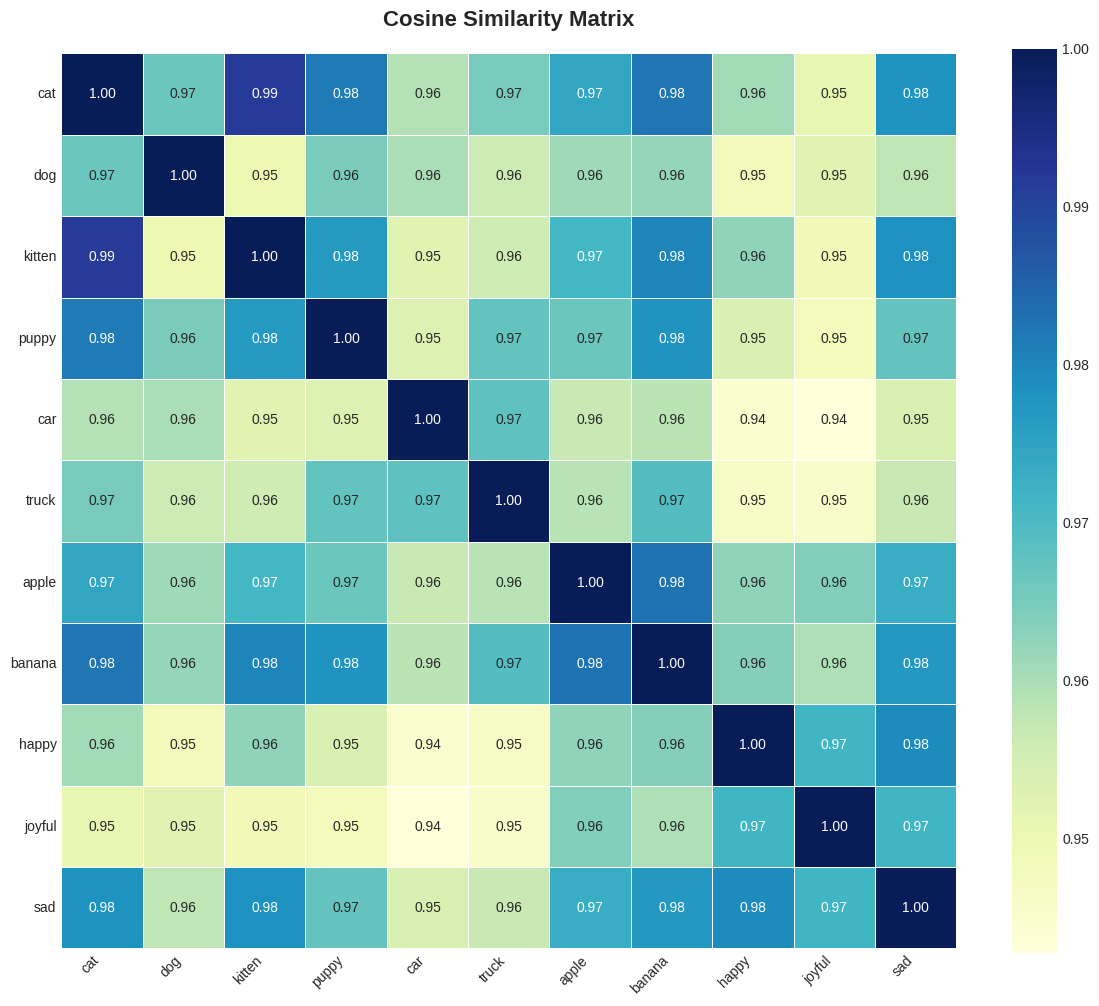

### 🔍 Key Similarities:

- **cat ↔ dog**: 0.967 (🟢 Very High)

- **cat ↔ kitten**: 0.992 (🟢 Very High)

- **dog ↔ puppy**: 0.965 (🟢 Very High)

- **car ↔ truck**: 0.968 (🟢 Very High)

- **apple ↔ banana**: 0.983 (🟢 Very High)

- **happy ↔ joyful**: 0.972 (🟢 Very High)

- **cat ↔ apple**: 0.975 (🟢 Very High)

In [ ]:
# ╔═══════════════════════════════════════════════════════════════╗
# ║  STEP 4: COSINE SIMILARITY MATRIX                             ║
# ╚═══════════════════════════════════════════════════════════════╝

display(Markdown("## 📐 STEP 4: MEASURING SIMILARITY"))
display(Markdown("Using cosine similarity to compare word vectors..."))

# Calculate similarity matrix
vectors = np.array([embeddings[word] for word in words])
similarities = cosine_similarity(vectors)

# Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(similarities, xticklabels=words, yticklabels=words,
            cmap='YlGnBu', annot=True, fmt='.2f',
            square=True, linewidths=0.5)
plt.title('Cosine Similarity Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Highlight interesting pairs
display(Markdown("### 🔍 Key Similarities:"))
interesting_pairs = [
    ("cat", "dog"),
    ("cat", "kitten"),
    ("dog", "puppy"),
    ("car", "truck"),
    ("apple", "banana"),
    ("happy", "joyful"),
    ("cat", "apple"),  # Should be low
]

for word1, word2 in interesting_pairs:
    idx1, idx2 = words.index(word1), words.index(word2)
    sim = similarities[idx1][idx2]

    # Color code
    if sim > 0.8:
        strength = "🟢 Very High"
    elif sim > 0.6:
        strength = "🟡 High"
    elif sim > 0.4:
        strength = "🟠 Medium"
    else:
        strength = "🔴 Low"

    display(Markdown(f"- **{word1} ↔ {word2}**: {sim:.3f} ({strength})"))



## 🎨 STEP 5: VISUALIZING VECTOR SPACE

Reducing 768 dimensions to 2D using PCA...

**Explained variance:** 46.33%

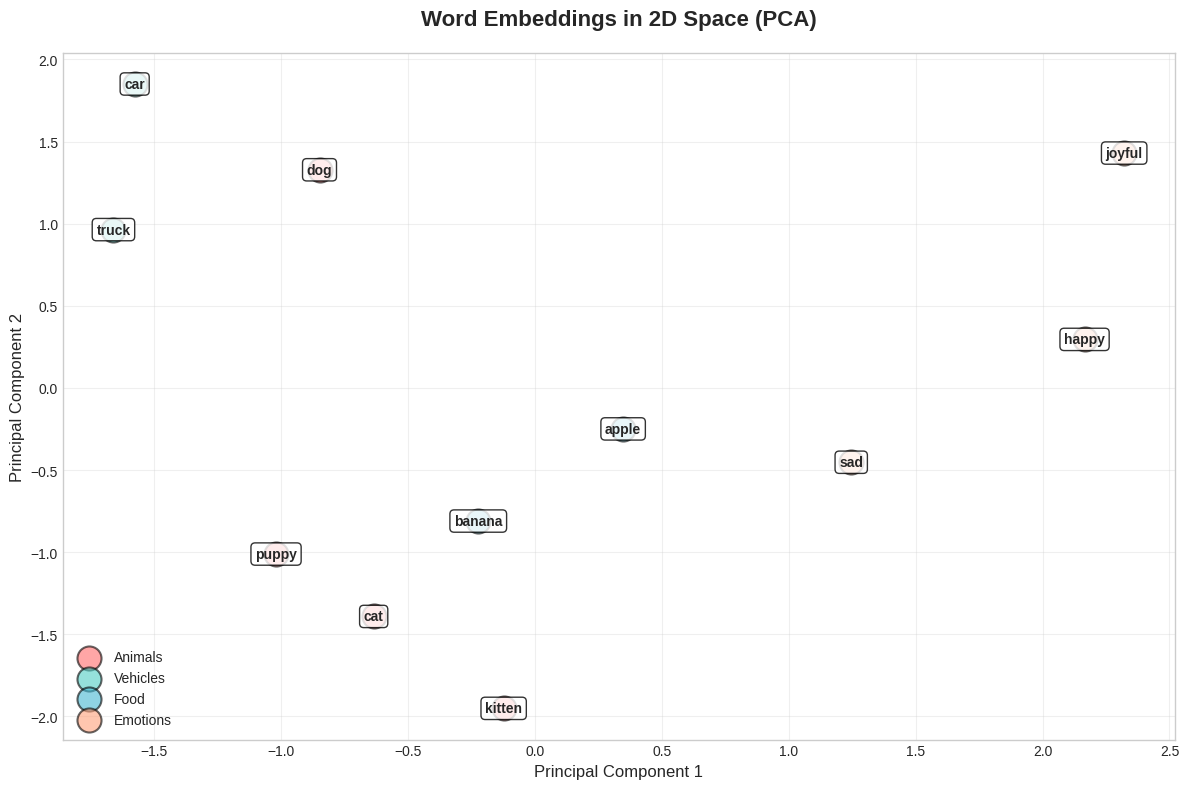

In [ ]:
# ╔═══════════════════════════════════════════════════════════════╗
# ║  STEP 5: 2D VISUALIZATION                                     ║
# ╚═══════════════════════════════════════════════════════════════╝

display(Markdown("## 🎨 STEP 5: VISUALIZING VECTOR SPACE"))
display(Markdown("Reducing 768 dimensions to 2D using PCA..."))

# Reduce to 2D
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(vectors)
explained_var = sum(pca.explained_variance_ratio_)

display(Markdown(f"**Explained variance:** {explained_var:.2%}"))

# Create plot
plt.figure(figsize=(12, 8))

# Define categories for coloring
categories = {
    'Animals': ['cat', 'dog', 'kitten', 'puppy'],
    'Vehicles': ['car', 'truck'],
    'Food': ['apple', 'banana'],
    'Emotions': ['happy', 'joyful', 'sad']
}

colors = {'Animals': '#FF6B6B', 'Vehicles': '#4ECDC4',
          'Food': '#45B7D1', 'Emotions': '#FFA07A'}

# Plot each category
for category, cat_words in categories.items():
    indices = [i for i, word in enumerate(words) if word in cat_words]
    if indices:
        x = [reduced_vectors[i, 0] for i in indices]
        y = [reduced_vectors[i, 1] for i in indices]
        plt.scatter(x, y, c=colors[category], s=300,
                   label=category, alpha=0.6, edgecolors='black', linewidth=1.5)

        # Add labels
        for i, idx in enumerate(indices):
            plt.annotate(words[idx], (x[i], y[i]), fontsize=10,
                        ha='center', va='center', fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.title('Word Embeddings in 2D Space (PCA)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel(f'Principal Component 1', fontsize=12)
plt.ylabel(f'Principal Component 2', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [ ]:
# ╔═══════════════════════════════════════════════════════════════╗
# ║  STEP 6: INTERACTIVE 3D VISUALIZATION                         ║
# ╚═══════════════════════════════════════════════════════════════╝

display(Markdown("## 🌌 STEP 6: INTERACTIVE 3D VISUALIZATION"))
display(Markdown("*Rotate and zoom to explore the vector space!*"))

# Reduce to 3D
pca_3d = PCA(n_components=3)
reduced_3d = pca_3d.fit_transform(vectors)
explained_var_3d = sum(pca_3d.explained_variance_ratio_)

display(Markdown(f"**3D Explained variance:** {explained_var_3d:.2%}"))

# Create interactive 3D plot
fig = go.Figure(data=[go.Scatter3d(
    x=reduced_3d[:, 0],
    y=reduced_3d[:, 1],
    z=reduced_3d[:, 2],
    mode='markers+text',
    marker=dict(
        size=8,
        color=[colors.get(cat, '#999999') for word in words
               for cat, cat_words in categories.items() if word in cat_words],
        opacity=0.8,
        line=dict(width=2, color='black')
    ),
    text=words,
    textposition='top center',
    textfont=dict(size=12, color='black')
)])

fig.update_layout(
    title='Interactive 3D Word Embeddings',
    scene=dict(
        xaxis_title='PC 1',
        yaxis_title='PC 2',
        zaxis_title='PC 3',
        aspectmode='cube'
    ),
    height=700,
    showlegend=False
)

fig.show()



## 🌌 STEP 6: INTERACTIVE 3D VISUALIZATION

*Rotate and zoom to explore the vector space!*

**3D Explained variance:** 59.10%

In [ ]:
# ╔═══════════════════════════════════════════════════════════════╗
# ║  STEP 7: FIND SIMILAR WORDS                                   ║
# ╚═══════════════════════════════════════════════════════════════╝

display(Markdown("## 🔎 STEP 7: FIND SIMILAR WORDS"))
display(Markdown("Enter a word to find its nearest neighbors..."))

def find_similar_words(query_word, embeddings, top_k=5):
    """Find most similar words to query"""
    if query_word not in embeddings:
        # Generate embedding for new word
        inputs = tokenizer(query_word, return_tensors='pt')
        with torch.no_grad():
            outputs = model(**inputs)
        query_embedding = outputs.last_hidden_state[0, 0, :].numpy()
    else:
        query_embedding = embeddings[query_word]

    # Calculate similarities
    all_words = list(embeddings.keys())
    all_vectors = np.array([embeddings[w] for w in all_words])
    sims = cosine_similarity([query_embedding], all_vectors)[0]

    # Get top-k
    top_indices = np.argsort(sims)[::-1][:top_k+1]  # +1 to include query itself
    results = [(all_words[i], sims[i]) for i in top_indices]

    return results

# Demo with a few words
demo_words = ["cat", "happy", "car"]

for query in demo_words:
    display(Markdown(f"### Words similar to **'{query}'**:"))
    results = find_similar_words(query, embeddings, top_k=4)

    for word, sim in results:
        if word == query:
            display(Markdown(f"- **{word}** ({sim:.3f}) ← query"))
        else:
            display(Markdown(f"- {word} ({sim:.3f})"))
    display(Markdown(""))  # Empty line



## 🔎 STEP 7: FIND SIMILAR WORDS

Enter a word to find its nearest neighbors...

### Words similar to **'cat'**:

- **cat** (1.000) ← query

- kitten (0.992)

...

- **car** (1.000) ← query

- truck (0.968)

- dog (0.960)

- cat (0.959)

- banana (0.958)

In [ ]:
# ╔═══════════════════════════════════════════════════════════════╗
# ║  STEP 8: TRY YOUR OWN WORDS!                                  ║
# ╚═══════════════════════════════════════════════════════════════╝

display(Markdown("## 🎯 STEP 8: EXPERIMENT YOURSELF!"))
display(Markdown("Try your own words below:"))

# Interactive widget
from ipywidgets import interact, widgets

@interact(word1="cat", word2="dog", word3="apple")
def compare_words(word1, word2, word3):
    """Interactive word comparison"""
    test_words = [word1, word2, word3]

    # Generate embeddings if needed
    test_embeddings = {}
    for w in test_words:
        if w in embeddings:
            test_embeddings[w] = embeddings[w]
        else:
            inputs = tokenizer(w, return_tensors='pt')
            with torch.no_grad():
                outputs = model(**inputs)
            test_embeddings[w] = outputs.last_hidden_state[0, 0, :].numpy()

    # Calculate similarities
    vectors = np.array([test_embeddings[w] for w in test_words])
    sims = cosine_similarity(vectors)

    # Display
    display(Markdown(f"### Similarity Matrix"))
    plt.figure(figsize=(8, 6))
    sns.heatmap(sims, xticklabels=test_words, yticklabels=test_words,
               cmap='YlGnBu', annot=True, fmt='.3f')
    plt.title('Your Words', fontsize=14, fontweight='bold')
    plt.show()

    display(Markdown(f"""
    **Findings:**
    - {word1} ↔ {word2}: {sims[0,1]:.3f}
    - {word1} ↔ {word3}: {sims[0,2]:.3f}
    - {word2} ↔ {word3}: {sims[1,2]:.3f}
    """))



## 🎯 STEP 8: EXPERIMENT YOURSELF!

Try your own words below:

interactive(children=(Text(value='cat', description='word1'), Text(value='dog', description='word2'), Text(val…

In [ ]:
# ╔═══════════════════════════════════════════════════════════════╗
# ║  SUMMARY & NEXT STEPS                                         ║
# ╚═══════════════════════════════════════════════════════════════╝

display(Markdown("""
## 🎉 CONGRATULATIONS!

You've just explored how LLMs process words!

### ✅ What You Learned:
1. **Tokenization** - Breaking text into subword units
2. **Embeddings** - Converting tokens to 768-dimensional vectors
3. **Similarity** - Measuring semantic relationships with cosine similarity
4. **Vector Space** - Visualizing how similar words cluster together

### 🚀 Next Steps:
- Try different words in Step 8
- Explore larger models (GPT-2, RoBERTa)
- Build a semantic search engine
- Create word analogies (king - man + woman = ?)

### 📚 Resources:
- [Hugging Face Transformers](https://huggingface.co/docs/transformers)
- [Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/)
- [Sentence Transformers](https://www.sbert.net/)

---
**Created for: How Do AI Models "Read"? Presentation**
"""))

# Save embeddings for later use
import pickle
with open('word_embeddings.pkl', 'wb') as f:
    pickle.dump(embeddings, f)

display(Markdown("💾 **Embeddings saved to `word_embeddings.pkl`**"))





## 🎉 CONGRATULATIONS!

You've just explored how LLMs process words!

### ✅ What You Learned:
1. **Tokenization** - Breaking text into subword units
2. **Embeddings** - Converting tokens to 768-dimensional vectors
3. **Similarity** - Measuring semantic relationships with cosine similarity
4. **Vector Space** - Visualizing how similar words cluster together

### 🚀 Next Steps:
- Try different words in Step 8
- Explore larger models (GPT-2, RoBERTa)
- Build a semantic search engine
- Create word analogies (king - man + woman = ?)

### 📚 Resources:
- [Hugging Face Transformers](https://huggingface.co/docs/transformers)
- [Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/)
- [Sentence Transformers](https://www.sbert.net/)

---
**Created for: How Do AI Models "Read"? Presentation**


💾 **Embeddings saved to `word_embeddings.pkl`**